In [72]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [73]:
# Load the SMS Spam dataset directly from GitHub

url = "https://raw.githubusercontent.com/mohitgupta-1O1/Kaggle-SMS-Spam-Collection-Dataset-/master/spam.csv"

df = pd.read_csv(url, encoding="latin-1")

# Display the first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [74]:
# Check the dataset structure

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())



Dataset shape: (5572, 5)

Column names:
['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']


In [75]:
# Keep only the required columns

df = df[["v1", "v2"]]

# Rename columns for clarity

df.columns = ["label", "message"]

# Check the cleaned dataset

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (5572, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [76]:
# Check the number of spam and ham messages

label_counts = df["label"].value_counts()

print("Message counts:")
print(label_counts)

print("\nMessage percentages:")
print((label_counts / len(df) * 100).round(2))

Message counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Message percentages:
label
ham     86.59
spam    13.41
Name: count, dtype: float64


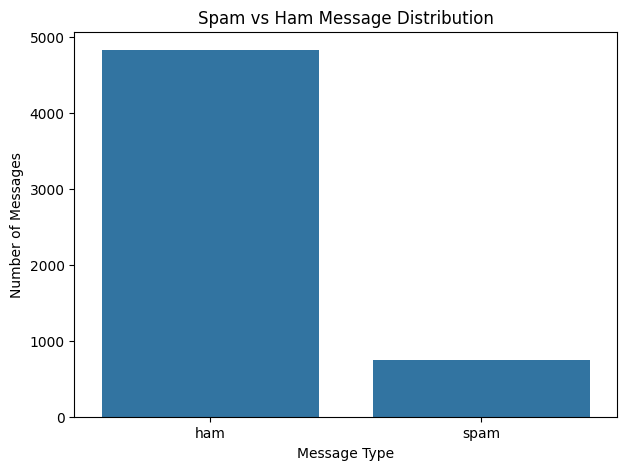

In [77]:
# Visualize spam vs ham distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    x="label",
    data=df
)

plt.title("Spam vs Ham Message Distribution")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")

plt.show()

In [78]:
# Text preprocessing

import string

# Define stopwords
stop_words = set("""
i me my myself we our ours ourselves you your yours yourself yourselves
he him his himself she her hers herself it its itself they them their theirs
themselves what which who whom this that these those am is are was were be
been being have has had having do does did doing a an the and but if or
because as until while of at by for with about against between into through
during before after above below to from up down in out on off over under
again further then once here there when where why how all any both each few
more most other some such no nor not only own same so than too very s t can
will just don should now
""".split())

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

# Apply preprocessing
df["clean_message"] = df["message"].apply(preprocess_text)

# Display original and cleaned messages
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## TF-IDF (Term Frequency–Inverse Document Frequency)

TF-IDF is a text feature extraction technique that converts text into numerical values that machine learning models can understand.

It measures how important a word is within a message compared with how frequently that word appears across all messages.

- **Term Frequency (TF):** Measures how frequently a word appears in a particular message.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear frequently across many messages.
- **TF-IDF:** Combines TF and IDF to give higher importance to words that are more useful for distinguishing messages.

In this project, TF-IDF will convert the cleaned SMS messages into numerical feature vectors that will be used by the machine learning classifiers.

In [79]:
# Convert text messages into TF-IDF features

tfidf_vectorizer = TfidfVectorizer()

X = tfidf_vectorizer.fit_transform(df["clean_message"])

print("TF-IDF matrix shape:", X.shape)

TF-IDF matrix shape: (5572, 9379)


In [80]:
# Convert labels into numerical values

df["label_num"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print(df[["label", "label_num"]].head())

  label  label_num
0   ham          0
1   ham          0
2  spam          1
3   ham          0
4   ham          0


In [81]:
# Separate features and target

y = df["label_num"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4457
Testing samples: 1115


In [82]:
# Train Multinomial Naive Bayes classifier

nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test)

print("Multinomial Naive Bayes model trained successfully!")

Multinomial Naive Bayes model trained successfully!


In [83]:
# Evaluate Multinomial Naive Bayes

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes Performance")
print("-----------------------------------")
print("Accuracy :", round(accuracy_nb, 4))
print("Precision:", round(precision_nb, 4))
print("Recall   :", round(recall_nb, 4))
print("F1-score :", round(f1_nb, 4))

Multinomial Naive Bayes Performance
-----------------------------------
Accuracy : 0.9623
Precision: 1.0
Recall   : 0.7181
F1-score : 0.8359


In [84]:
# Classification report for Multinomial Naive Bayes

print("Classification Report - Multinomial Naive Bayes")
print()

print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=["Ham", "Spam"]
    )
)

Classification Report - Multinomial Naive Bayes

              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



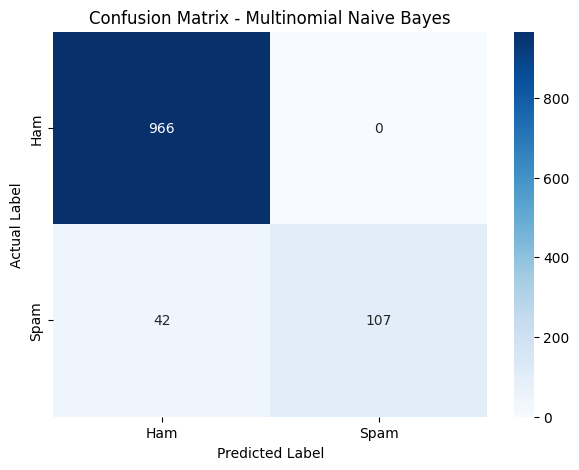

In [85]:
# Confusion matrix for Multinomial Naive Bayes

cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Multinomial Naive Bayes")

plt.show()

In [86]:
# Train Logistic Regression classifier

lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [87]:
# Evaluate Logistic Regression

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_lr, 4))
print("Precision:", round(precision_lr, 4))
print("Recall   :", round(recall_lr, 4))
print("F1-score :", round(f1_lr, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.9516
Precision: 0.9897
Recall   : 0.6443
F1-score : 0.7805


In [88]:
# Classification report for Logistic Regression

print("Classification Report - Logistic Regression")
print()

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Ham", "Spam"]
    )
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       966
        Spam       0.99      0.64      0.78       149

    accuracy                           0.95      1115
   macro avg       0.97      0.82      0.88      1115
weighted avg       0.95      0.95      0.95      1115



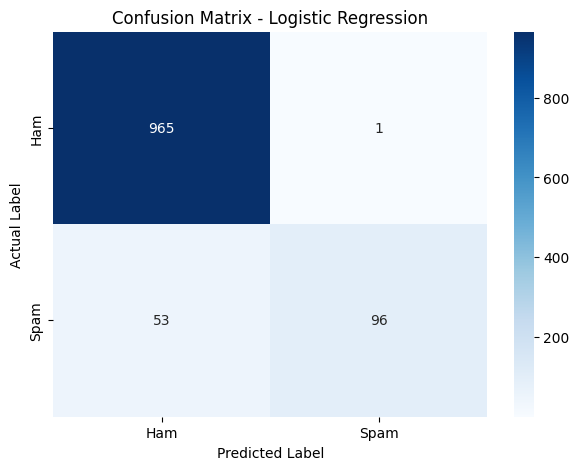

In [89]:
# Confusion matrix for Logistic Regression

cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [90]:
# Compare model performance

model_comparison = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr
    ],
    "Precision": [
        precision_nb,
        precision_lr
    ],
    "Recall": [
        recall_nb,
        recall_lr
    ],
    "F1-score": [
        f1_nb,
        f1_lr
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Multinomial Naive Bayes,0.9623,1.0000,0.7181,0.8359
1,Logistic Regression,0.9516,0.9897,0.6443,0.7805


## Model Comparison and Best Model

Two machine learning classifiers were trained and evaluated: Multinomial Naive Bayes and Logistic Regression.

Multinomial Naive Bayes achieved an accuracy of 96.23%, precision of 100.00%, recall of 71.81%, and F1-score of 83.59%.

Logistic Regression achieved an accuracy of 95.16%, precision of 98.97%, recall of 64.43%, and F1-score of 78.05%.

Based on these results, Multinomial Naive Bayes is selected as the best-performing model. It achieved higher accuracy, precision, recall, and F1-score than Logistic Regression.

Recall is particularly important in spam detection because a false negative means that an actual spam message is classified as legitimate (ham). A higher recall helps the system identify more of the actual spam messages.

Therefore, Multinomial Naive Bayes is used as the final model for this project.

## Why Recall Is Important for Spam Detection

Recall measures how many of the actual spam messages are correctly identified by the model.

In spam detection, a false negative occurs when an actual spam message is incorrectly classified as ham. This can allow unwanted or potentially harmful messages to reach the user's inbox.

Therefore, recall is particularly important because we want to detect as many actual spam messages as possible.

However, precision is also important because incorrectly marking legitimate messages as spam can cause important messages to be missed.

In this project, Multinomial Naive Bayes achieved a spam recall of 71.81% and a spam precision of 100.00%, providing a good balance between detecting spam and avoiding false spam predictions.

In [71]:
# Install WordCloud library

!pip install wordcloud -q
from wordcloud import WordCloud

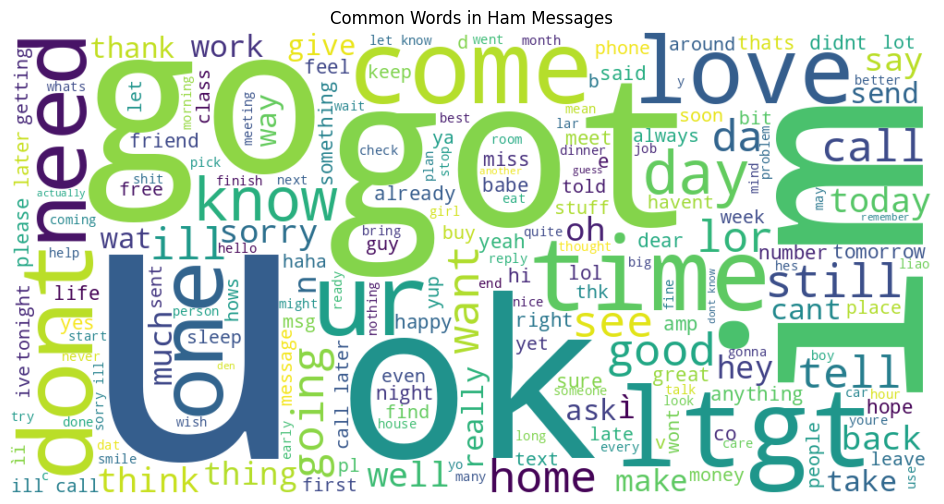

In [91]:
# WordCloud for ham messages

ham_text = " ".join(
    df[df["label"] == "ham"]["clean_message"]
)

ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(ham_text)

plt.figure(figsize=(12, 6))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Ham Messages")
plt.show()

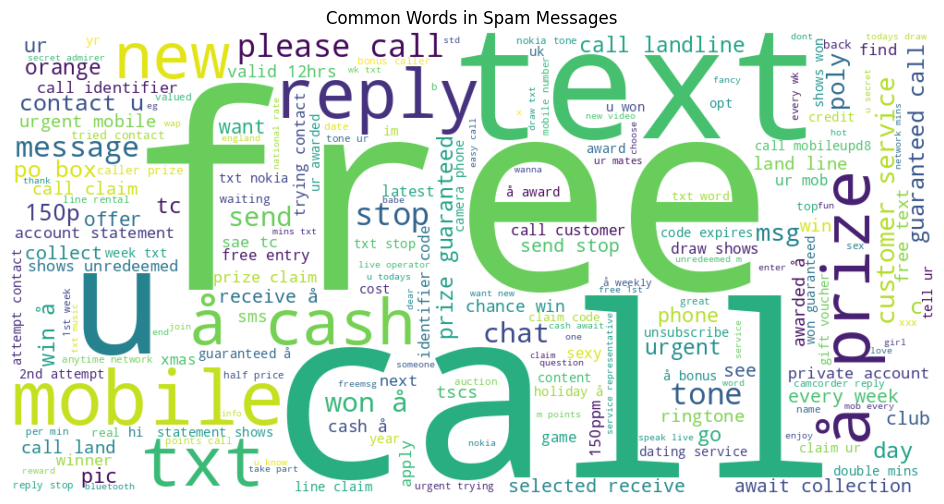

In [92]:
# WordCloud for spam messages



spam_text = " ".join(
    df[df["label"] == "spam"]["clean_message"]
)

spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Common Words in Spam Messages")
plt.show()

## Bonus: WordCloud Visualizations

The following WordCloud visualizations show the most frequently occurring words in spam and ham messages. They provide a visual representation of common vocabulary in each class.

## Conclusion

In this project, machine learning and Natural Language Processing techniques were used to classify messages as spam or ham.

The messages were cleaned through text preprocessing and converted into numerical features using TF-IDF. Two classification models, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, and F1-score.

Multinomial Naive Bayes performed better than Logistic Regression, achieving an accuracy of 96.23%, precision of 100.00%, recall of 71.81%, and F1-score of 83.59% on the test data. Therefore, Multinomial Naive Bayes was selected as the best-performing model for this project.

The results demonstrate that TF-IDF combined with a suitable classification algorithm can effectively distinguish spam messages from legitimate messages. Recall was given particular importance because correctly identifying actual spam messages is an important objective of a spam detection system.